# Step 1: Environment & Dependency Setup

In [1]:
!pip install soundfile torchaudio scikit-learn seaborn tqdm -q

## Imports and Reproducibility

In [2]:
import random
import numpy as np
from pathlib import Path
import pandas as pd
import soundfile as sf
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
import torchaudio.transforms as T
from torchaudio.transforms import FrequencyMasking, TimeMasking

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import shutil
import time
import torchvision.models as models
import torch.nn as nn
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Subset
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


# Step 2: Data Preparation

In [4]:
source_folder = "/content/drive/MyDrive/SEM_2_DOC/FinalProjectDL/Deepfake_Audio_Project/EnvSDD-Development (Unzipped Files)"
output_audio_path = "/content/data/development"
local_temp_dir = "/content/temp_dataset"

os.makedirs(output_audio_path, exist_ok=True)
os.makedirs(local_temp_dir, exist_ok=True)

# Step 1: Copy ALL parts (.zip and .z01, .z02, etc.) to local disk
print("Copying all dataset parts to local disk (this may take a few minutes)...")
!cp "{source_folder}"/development.z* {local_temp_dir}/
!cp "{source_folder}"/development.zip {local_temp_dir}/

# Step 2: Extract using the main .zip file as the entry point
print("📦 Extracting multi-part archive...")
# 7z automatically handles .z01, .z02 if they are in the same folder as the .zip
!7z x {local_temp_dir}/development.zip -o{output_audio_path} -mmt=on -y -bd > /dev/null

# Step 3: Verify
wav_count = len([f for r, d, files in os.walk(output_audio_path) for f in files if f.endswith('.wav')])
print(f"✅ Extraction complete. Found {wav_count} .wav files.")

Copying all dataset parts to local disk (this may take a few minutes)...
📦 Extracting multi-part archive...
✅ Extraction complete. Found 178765 .wav files.


In [6]:
# 1. Install the correct tool
# !apt-get install p7zip-full -y

# 2. Extract EnvSDD Development (The split archive)
# Replace the path below with your actual Drive folder path
env_sdd_path = "/content/drive/MyDrive/SEM_2_DOC/FinalProjectDL/Deepfake_Audio_Project"

# print('Extracting EnvSDD Development (Split Archive)...')
# !7z x "{env_sdd_path}/EnvSDD-Development.zip" -o/content/data/development -y

# 3. Extract EnvSDD Test
print('Extracting EnvSDD Test...')
!7z x "{env_sdd_path}/EnvSDD-Test.zip" -o/content/data/test_raw -y

# 4. Extract Lens-DF
print('Extracting Lens-DF...')
!7z x "{env_sdd_path}/LENS-DF Sample Data.zip" -o/content/data/Lens-DF -y

print('✅ All datasets extracted to local /content/data/')

Extracting EnvSDD Test...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,8 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/SEM_2_DO . rojectDL/Deepfake_Audio_Project/                                                                            1 file, 5776019299 bytes (5509 MiB)

Extracting archive: /content/drive/MyDrive/SEM_2_DOC/FinalProjectDL/Deepfake_Audio_Project/EnvSDD-Test.zip
--
Path = /content/drive/MyDrive/SEM_2_DOC/FinalProjectDL/Deepfake_Audio_Project/EnvSDD-Test.zip
Type = zip
Physical Size = 5776019299
64-bit = +

  0%      0% - test.z01                 1% - test.z01                 2% - test.

In [7]:
print("🔊 Extracting Lens-DF Dev and Eval audio...")
!unzip -n -q /content/data/Lens-DF/dev.zip -d /content/data/Lens-DF/dev
!unzip -n -q /content/data/Lens-DF/eval.zip -d /content/data/Lens-DF/eval

🔊 Extracting Lens-DF Dev and Eval audio...


# Constants & Augmentation

All audio constants defined **once** and shared by both dataset classes.
This guarantees every tensor has shape `[1, 128, 313]` and prevents
the `stack expects equal size` DataLoader crash.


In [8]:
# Both datasets use these constants — changing here updates everywhere
SAMPLE_RATE   = 16000           # Hz
DURATION      = 5.0             # seconds per clip
NUM_SAMPLES   = int(SAMPLE_RATE * DURATION)   # 80,000 waveform samples

# Mel Spectrogram settings
# n_fft=2048: better frequency resolution for noisy LENS-DF audio
# hop_length=256: finer time resolution vs default 512
# f_max=8000: deepfake artifacts mostly below 8kHz
N_FFT         = 2048
HOP_LENGTH    = 256
N_MELS        = 128
F_MIN         = 20
F_MAX         = 8000

# Fixed output time frames — all tensors same size for DataLoader stacking
TARGET_FRAMES = NUM_SAMPLES // HOP_LENGTH + 1   # = 313

print(f'Audio constants set')
print(f'Output shape per sample: [1, {N_MELS}, {TARGET_FRAMES}]  (C x Freq x Time)')

Audio constants set
Output shape per sample: [1, 128, 313]  (C x Freq x Time)


### SpecAugment

Randomly masks frequency bands and time steps during training.
Forces the model to learn generalizable artifact patterns rather than
dataset-specific shortcuts like background noise signatures.

- `freq_mask_param=15` — masks up to 15 mel bins (~12% of 128 total)
- `time_mask_param=40` — masks up to 40 time frames
- `num_masks=2` — two independent masks per axis



In [9]:
class SpecAugment(nn.Module):
    def __init__(self, freq_mask_param=15, time_mask_param=40, num_masks=2):
        super().__init__()
        self.freq_maskers = nn.ModuleList(
            [FrequencyMasking(freq_mask_param=freq_mask_param) for _ in range(num_masks)]
        )
        self.time_maskers = nn.ModuleList(
            [TimeMasking(time_mask_param=time_mask_param) for _ in range(num_masks)]
        )

    def forward(self, x):
        for fm in self.freq_maskers:
            x = fm(x)
        for tm in self.time_maskers:
            x = tm(x)
        return x

## Dataset Classes

Both datasets produce tensors of identical shape `[1, 128, 313]`.

In [10]:
class EnvSDDDataset(Dataset):
    def __init__(self, root_dir, sample_rate=SAMPLE_RATE, duration=DURATION, augment=False):
        self.root_dir    = Path(root_dir)
        self.sample_rate = sample_rate
        self.num_samples = int(sample_rate * duration)
        self.augment     = augment

        self.files, self.labels = [], []
        for label_name, label in [('real', 0), ('fake', 1)]:
            folder = self.root_dir / label_name
            if not folder.exists():
                print(f'  [WARNING] Not found: {folder}')
                continue
            found = list(folder.rglob('*.wav'))
            self.files.extend(found)
            self.labels.extend([label] * len(found))

        print(f'  EnvSDD [{Path(root_dir).name}]: {len(self.files)} files '
              f'| real={self.labels.count(0)}, fake={self.labels.count(1)}')

        self.resamplers = {}
        self.mel = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            f_min=20,
            f_max=8000
        )
        self.db       = T.AmplitudeToDB()
        self.spec_aug = SpecAugment(freq_mask_param=15, time_mask_param=40, num_masks=2)

    def __len__(self): return len(self.files)

    def _load_audio(self, path):
        audio, sr = sf.read(str(path), always_2d=True)
        audio = audio.mean(axis=1)
        w = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
        if sr != self.sample_rate:
            if sr not in self.resamplers:
                self.resamplers[sr] = T.Resample(orig_freq=sr, new_freq=self.sample_rate)
            w = self.resamplers[sr](w)
        return w

    def __getitem__(self, idx):
        w     = self._load_audio(self.files[idx])
        label = self.labels[idx]

        # Pad if shorter than target
        if w.shape[1] < self.num_samples:
            w = nn.functional.pad(w, (0, self.num_samples - w.shape[1]))

        # Always crop to exact length
        start = random.randint(0, w.shape[1] - self.num_samples) if self.augment else 0
        w = w[:, start : start + self.num_samples]

        # Mel spectrogram + normalize
        x = self.db(self.mel(w))
        x = (x - x.mean()) / (x.std() + 1e-6)

        # Stronger augmentation for EnvSDD (clean audio needs more noise)
        if self.augment:
            # standard noise level
            x = x + torch.randn_like(x) * 0.005
            # always apply SpecAugment
            x = self.spec_aug(x)

        # Safety clamp — same as LensDFDataset, guarantees matching shape
        if x.shape[2] > TARGET_FRAMES:
            x = x[:, :, :TARGET_FRAMES]
        elif x.shape[2] < TARGET_FRAMES:
            x = nn.functional.pad(x, (0, TARGET_FRAMES - x.shape[2]))

        return x, torch.tensor(label, dtype=torch.long)

In [11]:
class LensDFDataset(Dataset):
    def __init__(self, root_dir, csv_file, sample_rate=SAMPLE_RATE, duration=DURATION, augment=False):
        self.root_dir    = Path(root_dir)
        self.augment     = augment
        self.sample_rate = sample_rate
        self.num_samples = int(sample_rate * duration)

        df = pd.read_csv(csv_file)
        df = df.drop(columns=[c for c in df.columns if str(c).startswith('Unnamed:')])

        self.files, self.labels = [], []
        for _, row in df.iterrows():
            file_name = os.path.basename(row['file'])
            path = self.root_dir / 'wavs' / file_name
            if path.exists():
                self.files.append(path)
                self.labels.append(0 if row['label'] == 'bonafide' else 1)

        print(f"  LensDF: {len(self.files)} files found in {Path(root_dir).name}")

        self.resamplers = {}
        self.mel = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            f_min=20,
            f_max=8000
        )
        self.db       = T.AmplitudeToDB()
        self.spec_aug = SpecAugment(freq_mask_param=15, time_mask_param=40, num_masks=2)

    def __len__(self): return len(self.files)

    def _load_audio(self, path):
        audio, sr = sf.read(str(path), always_2d=True)
        audio = audio.mean(axis=1)
        w = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
        if sr != self.sample_rate:
            if sr not in self.resamplers:
                self.resamplers[sr] = T.Resample(orig_freq=sr, new_freq=self.sample_rate)
            w = self.resamplers[sr](w)
        return w

    def __getitem__(self, idx):
        w     = self._load_audio(self.files[idx])
        label = self.labels[idx]

        # Pad if shorter than target
        if w.shape[1] < self.num_samples:
            w = nn.functional.pad(w, (0, self.num_samples - w.shape[1]))

        # Always crop to exact length
        start = random.randint(0, w.shape[1] - self.num_samples) if self.augment else 0
        w = w[:, start : start + self.num_samples]

        # Mel spectrogram + normalize
        x = self.db(self.mel(w))
        x = (x - x.mean()) / (x.std() + 1e-6)

        # Lighter augmentation for Lens-DF (already noisy audio)
        if self.augment:
            # half of EnvSDD noise
            x = x + torch.randn_like(x) * 0.002
            # only 50% of the time
            if random.random() > 0.5:
                x = self.spec_aug(x)

        # Safety clamp — guarantees fixed time dimension
        if x.shape[2] > TARGET_FRAMES:
            x = x[:, :, :TARGET_FRAMES]
        elif x.shape[2] < TARGET_FRAMES:
            x = nn.functional.pad(x, (0, TARGET_FRAMES - x.shape[2]))

        return x, torch.tensor(label, dtype=torch.long)

In [12]:
print(f'\n📐 Both datasets output shape: [1, {N_MELS}, {TARGET_FRAMES}]')
print(f'   (n_fft={N_FFT}, hop_length={HOP_LENGTH}, duration={DURATION}s)')


📐 Both datasets output shape: [1, 128, 313]
   (n_fft=2048, hop_length=256, duration=5.0s)


## Model — DeepfakeResNet

**Base:** ResNet-18 pretrained on ImageNet, adapted for single-channel mel spectrograms.

**Key modifications:**
- `InstanceNorm2d` before the network — normalizes per-sample to reduce domain sensitivity
- `conv1` changed 3-channel → 1-channel (pre-trained weights summed across RGB)
- Final FC: `Dropout(0.5) -> Linear(512, 2)`

**Why ResNet-18 over custom CNN:**
The custom CNN had ~64K parameters and was underfitting on cross-domain data.
ResNet-18 has 11M pre-trained parameters that transfer well to spectrogram texture features.


In [13]:
class DeepfakeResNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DeepfakeResNet, self).__init__()

        # Load Pre-trained ResNet18
        self.resnet = models.resnet18(weights='DEFAULT')

        # Instance Normalization (The Domain Bridge)
        # Standardizes the input to ignore 'clean vs noisy' differences
        self.inst_norm = nn.InstanceNorm2d(1, affine=False)

        # Modify Input Layer for 1-channel spectrograms
        # Save old weights before overwriting
        old_conv1 = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Preserve pre-trained features by summing the 3 original channels
        with torch.no_grad():
            self.resnet.conv1.weight.data = old_conv1.weight.data.sum(dim=1, keepdim=True)

        # Modify Final Layer for 2 classes (Real/Fake)
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_ftrs, 2)
        )

    def forward(self, x):
        # Apply Instance Norm BEFORE the ResNet layers
        x = self.inst_norm(x)
        return self.resnet(x)

# INITIALIZATION
# Re-run this whenever you modify the class above
model = DeepfakeResNet(dropout_rate=0.5).to(device)

# SANITY CHECK
_dummy = torch.randn(2, 1, 128, 157).to(device)
with torch.no_grad():
    _out = model(_dummy)
print(f"ResNet Initialized with InstanceNorm. Output shape: {_out.shape}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


ResNet Initialized with InstanceNorm. Output shape: torch.Size([2, 2])
Total Parameters: 11,171,266


## Helper Functions

- `make_balanced_sampler` — class-balanced WeightedRandomSampler
- `run_epoch` — unified train/eval pass
- `evaluate_full` — argmax evaluation (no threshold bias)
- `print_per_class_report` — detailed precision/recall/F1 per class
- `plot_confusion_matrix` — heatmap
- `plot_training_curves` — loss, F1, LENS-DF F1 over epochs
- `row` — metrics dict for final summary table


In [14]:
def make_balanced_sampler(labels):
    '''
    WeightedRandomSampler: every class appears equally in each batch.
    Essential when combining datasets with different class ratios.
    '''
    counts  = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=len(labels), replacement=True)


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    '''
    Single training or evaluation pass.
    Returns: (avg_loss, accuracy, precision_real, recall_real, f1_real)
    '''
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for x, y in tqdm(loader, desc='Train' if train else 'Eval ', leave=False):
            x, y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return (
        avg_loss,
        accuracy_score(all_labels, all_preds),
        precision_score(all_labels, all_preds, pos_label=0, zero_division=0),
        recall_score(all_labels, all_preds, pos_label=0, zero_division=0),
        f1_score(all_labels, all_preds, pos_label=0, zero_division=0)
    )


@torch.no_grad()
def evaluate_full(model, loader, device, dataset_name='Test'):
    '''
    Final evaluation using argmax — no probability threshold.
    A threshold biases predictions; argmax is the unbiased standard.
    '''
    model.eval()
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc=f'Eval [{dataset_name}]', leave=False):
        preds = torch.argmax(model(x.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
    return all_labels, all_preds


def print_per_class_report(labels, preds, dataset_name):
    print(f'\n' + '='*55)
    print(f'  Per-Class Report: {dataset_name}')
    print('='*55)
    print(f'  Accuracy: {accuracy_score(labels, preds):.4f}')
    print(classification_report(labels, preds,
        target_names=['Real (0)', 'Fake (1)'], digits=4, zero_division=0))
    return confusion_matrix(labels, preds)


def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix: {title}')
    plt.tight_layout(); plt.show()


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].plot(history['train_f1'], label='Train F1'); axes[1].plot(history['val_f1'], label='Val F1')
    axes[1].set_title('F1 Score'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    axes[2].plot(history['lens_f1'], label='LENS-DF Val F1', color='orange')
    axes[2].axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Target 0.80')
    axes[2].set_title('LENS-DF Val F1 (Model Save Target)'); axes[2].legend(); axes[2].set_xlabel('Epoch')
    plt.tight_layout(); plt.show()


def row(labels, preds):
    return {
        'Accuracy'       : round(accuracy_score(labels, preds), 4),
        'Precision Real' : round(precision_score(labels, preds, pos_label=0, zero_division=0), 4),
        'Recall Real'    : round(recall_score(labels, preds, pos_label=0, zero_division=0), 4),
        'F1 Real'        : round(f1_score(labels, preds, pos_label=0, zero_division=0), 4),
        'Precision Fake' : round(precision_score(labels, preds, pos_label=1, zero_division=0), 4),
        'Recall Fake'    : round(recall_score(labels, preds, pos_label=1, zero_division=0), 4),
        'F1 Fake'        : round(f1_score(labels, preds, pos_label=1, zero_division=0), 4),
        'Macro F1'       : round(f1_score(labels, preds, average='macro', zero_division=0), 4),
    }


## EnvSDD Data Splitting

Split raw EnvSDD audio into train / val / test partitions.
- **80% train, 10% val, 10% test**
- Split is performed per-class to maintain Real/Fake balance across splits

> **Run only once.** Files are physically moved into `split_data/` subfolders.
> Cell auto-skips if `split_data/` already exists.


In [15]:
# Define Paths (Fixed for double-nested folders)
base_path = "/content/data/development/development"
dest_path = "/content/data/development/split_data"

def get_all_wavs(folder_name):
    path = os.path.join(base_path, folder_name)
    wav_files = []
    if not os.path.exists(path):
        return []
    # Using os.walk to find all files recursively
    for root, dirs, files in os.walk(path):
        for file in files:
            # Case-insensitive check for .wav
            if file.lower().endswith(".wav"):
                wav_files.append(os.path.join(root, file))
    return wav_files

print(" Scanning for audio files...")
real_files = get_all_wavs("real_audio")
fake_files = get_all_wavs("fake_audio")

print(f" Found: {len(real_files):,} Real and {len(fake_files):,} Fake files.")

# Perform the Split and Copy
if len(real_files) > 0 and len(fake_files) > 0:
    # We map 'real_audio' source to 'real' destination folder
    for files, label_name in [(real_files, 'real'), (fake_files, 'fake')]:
        train, test_val = train_test_split(files, test_size=0.2, random_state=42)
        val, test = train_test_split(test_val, test_size=0.5, random_state=42)

        for subset, split_files in [('train', train), ('val', val), ('test', test)]:
            target_dir = os.path.join(dest_path, subset, label_name)
            os.makedirs(target_dir, exist_ok=True)

            print(f"Copying {len(split_files):,} files to {subset}/{label_name}")
            # Use shutil.copy to keep original files in the dev folder
            for i, f in enumerate(tqdm(split_files, desc=f"Copying {subset}/{label_name}")):
                new_name = f"{i}_{os.path.basename(f)}"
                shutil.copy(f, os.path.join(target_dir, new_name))

    print("\n SUCCESS: All files copied and organized.")
else:
    print("\n Still found 0 files. Verify that base_path is exactly where 'real_audio' sits.")
    !ls /content/data/development/development

 Scanning for audio files...
 Found: 35,753 Real and 143,012 Fake files.
Copying 28,602 files to train/real


Copying train/real: 100%|██████████| 28602/28602 [01:04<00:00, 443.59it/s]


Copying 3,575 files to val/real


Copying val/real: 100%|██████████| 3575/3575 [00:04<00:00, 769.11it/s] 


Copying 3,576 files to test/real


...

Copying 14,301 files to val/fake


Copying val/fake: 100%|██████████| 14301/14301 [00:38<00:00, 374.89it/s]


Copying 14,302 files to test/fake


Copying test/fake: 100%|██████████| 14302/14302 [00:35<00:00, 404.77it/s]


 SUCCESS: All files copied and organized.


## Paths & Training Configuration


In [16]:
# Dataset Paths
ENVSDD_TRAIN = '/content/data/development/split_data/train'
ENVSDD_VAL   = '/content/data/development/split_data/val'
ENVSDD_TEST  = '/content/data/development/split_data/test'

# LENS-DF dev (training + validation)
LENSDF_DEV_ROOT = '/content/data/Lens-DF/dev/dev/SEG4'
LENSDF_DEV_CSV  = '/content/data/Lens-DF/dev/dev/SEG4/data.csv'

# LENS-DF eval (final evaluation ONLY — never used during training)
LENSDF_EVAL_ROOT = '/content/data/Lens-DF/eval/eval'
LENSDF_EVAL_CSV  = '/content/data/Lens-DF/eval/eval/data.csv'

# Training Hyperparameters
BATCH_SIZE = 32
# Stage 1 combined pretraining epochs
NUM_EPOCHS = 20
RESNET_LR  = 1e-4

print('Paths and hyperparameters configured')
print(f'  LENS-DF Dev:  {LENSDF_DEV_ROOT}')
print(f'  LENS-DF Eval: {LENSDF_EVAL_ROOT}')

Paths and hyperparameters configured
  LENS-DF Dev:  /content/data/Lens-DF/dev/dev/SEG4
  LENS-DF Eval: /content/data/Lens-DF/eval/eval


## Dataset Building — Class-Matched Domain Balancing

**Problem with naive mixing:** EnvSDD has 143K samples, LENS-DF has ~10K.
A naive combined loader would train on 93% EnvSDD, causing the model to ignore LENS-DF patterns.

**Solution:** Randomly sample EnvSDD to exactly match LENS-DF's Real/Fake counts.
Result: 50% EnvSDD / 50% LENS-DF in every epoch, with identical class distribution.

**Validation:** Separate per-dataset loaders — never merged.
Model saved on **LENS-DF val F1** only, not combined F1.


In [17]:
print('Phase 1: Randomized Class-Matched & Domain-Balanced Dataset')

# Initialize datasets
# We keep augment=True for training to ensure the Gaussian noise is active
envsdd_train = EnvSDDDataset(ENVSDD_TRAIN, augment=True)
envsdd_val   = EnvSDDDataset(ENVSDD_VAL,   augment=False)
lensdf_dev_full = LensDFDataset(LENSDF_DEV_ROOT, LENSDF_DEV_CSV, augment=True)

# Split Lens-DF 80/20 (80% to help the model learn "Clean" features)
n_train_lens = int(len(lensdf_dev_full) * 0.8)
n_val_lens   = len(lensdf_dev_full) - n_train_lens
lens_train_ds, lens_val_ds = torch.utils.data.random_split(
    lensdf_dev_full, [n_train_lens, n_val_lens],
    generator=torch.Generator().manual_seed(42)
)

# Count Lens-DF train class distribution
lens_train_indices = lens_train_ds.indices
lens_train_labels = [lensdf_dev_full.labels[i] for i in lens_train_indices]
n_lens_real = lens_train_labels.count(0)
n_lens_fake = lens_train_labels.count(1)

# FIXED: Pull RANDOM matching counts from EnvSDD
# This ensures the model sees ALL environments (Metro, Square, Street, etc.)
all_env_real_idx = [i for i, l in enumerate(envsdd_train.labels) if l == 0]
all_env_fake_idx = [i for i, l in enumerate(envsdd_train.labels) if l == 1]

# Randomly sample to match Lens-DF counts
matched_real_idx = np.random.choice(all_env_real_idx, n_lens_real, replace=False).tolist()
matched_fake_idx = np.random.choice(all_env_fake_idx, n_lens_fake, replace=False).tolist()
envsdd_matched_indices = matched_real_idx + matched_fake_idx

envsdd_matched = Subset(envsdd_train, envsdd_matched_indices)
envsdd_matched_labels = [envsdd_train.labels[i] for i in envsdd_matched_indices]

print(f" Lens-DF train → Real: {n_lens_real} | Fake: {n_lens_fake}")
print(f" EnvSDD matched → Real: {len(matched_real_idx)} | Fake: {len(matched_fake_idx)} (Randomly Sampled)")

# Combine
combined_train  = ConcatDataset([envsdd_matched, lens_train_ds])
combined_labels = envsdd_matched_labels + lens_train_labels

train_loader = DataLoader(
    combined_train,
    batch_size=BATCH_SIZE,
    sampler=make_balanced_sampler(combined_labels),
    num_workers=4,
    pin_memory=True
)

# Separate val loaders (The "Gold Standard" for testing generalization)
lens_val_loader   = DataLoader(lens_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
envsdd_val_loader = DataLoader(envsdd_val,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"\nCombined Train: {len(combined_train):,} samples")
print(f"   Domain Mix: 50% EnvSDD | 50% Lens-DF")
print(f"   Class Mix:  {combined_labels.count(0):,} Real | {combined_labels.count(1):,} Fake")
print(f"Val Loaders Ready: EnvSDD ({len(envsdd_val)}) & Lens-DF ({len(lens_val_ds)})")

Phase 1: Randomized Class-Matched & Domain-Balanced Dataset
  EnvSDD [train]: 143011 files | real=28602, fake=114409
  EnvSDD [val]: 17876 files | real=3575, fake=14301
  LensDF: 10772 files found in SEG4
 Lens-DF train → Real: 4084 | Fake: 4533
 EnvSDD matched → Real: 4084 | Fake: 4533 (Randomly Sampled)

Combined Train: 17,234 samples
   Domain Mix: 50% EnvSDD | 50% Lens-DF
   Class Mix:  8,168 Real | 9,066 Fake
Val Loaders Ready: EnvSDD (17876) & Lens-DF (2155)


In [18]:
# Balance EnvSDD val to match Lens-DF val size
lens_val_size = len(lens_val_ds)
np.random.seed(42)
envsdd_val_indices = np.random.choice(len(envsdd_val), size=lens_val_size, replace=False)
envsdd_val_balanced = Subset(envsdd_val, envsdd_val_indices)

# Separate loaders (keep these separate — don't merge)
lens_val_loader = DataLoader(
    lens_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4
)
envsdd_val_loader = DataLoader(
    envsdd_val_balanced, batch_size=BATCH_SIZE, shuffle=False, num_workers=4
)

print(f"Balanced Val: EnvSDD={len(envsdd_val_balanced):,} | Lens-DF={len(lens_val_ds):,}")

Balanced Val: EnvSDD=2,155 | Lens-DF=2,155


In [19]:
print(f"# Check what's in your combined training set")
print(f"EnvSDD train: {len(envsdd_train)} samples")
print(f"  Real: {envsdd_train.labels.count(0)}")
print(f"  Fake: {envsdd_train.labels.count(1)}")

print(f"\nLens-DF train: {len(lens_train_ds)} samples")
lens_labels = [lensdf_dev_full.labels[i] for i in lens_train_ds.indices]
print(f"  Real: {lens_labels.count(0)}")
print(f"  Fake: {lens_labels.count(1)}")

print(f"\nCombined: {len(combined_train)}")
print(f"  Real: {combined_labels.count(0)}")
print(f"  Fake: {combined_labels.count(1)}")
print(f"  EnvSDD %: {len(envsdd_matched) / len(combined_train) * 100:.1f}%")

# Check what's in your combined training set
EnvSDD train: 143011 samples
  Real: 28602
  Fake: 114409

Lens-DF train: 8617 samples
  Real: 4084
  Fake: 4533

Combined: 17234
  Real: 8168
  Fake: 9066
  EnvSDD %: 50.0%


In [20]:
# Clean paths without the formatting characters
base_path = "/content/data/development/development"
dest_path = "/content/data/development/split_data"

print("Final Data Check")

if os.path.exists(dest_path):
    # Quick count check for peace of mind
    train_real = len(os.listdir(os.path.join(dest_path, "train/real")))
    train_fake = len(os.listdir(os.path.join(dest_path, "train/fake")))
    print(f" Data is organized! Train set: {train_real:,} Real | {train_fake:,} Fake")
    print("Status: Ready for Training.")
else:
    print("split_data folder not found. Please double-check extraction.")

Final Data Check
 Data is organized! Train set: 28,602 Real | 114,409 Fake
Status: Ready for Training.


### Lens-DF Data Contribution

- **Lens-DF Training Set:**
  - Real samples: **4,084**
  - Fake samples: **4,533**
  - Total: **8,617** samples

- **Lens-DF Validation Set:**
  - Real samples: (This is part of `lens_val_ds` but its real/fake counts aren't explicitly printed. We know there are 2,155 samples in total.)

This distribution ensures that Lens-DF contributes a significant portion of both real and fake samples to your training data.

In [21]:
# Combined Data
print("Final Combined Data Check...")

# This checks the actual data object created in Cell 122
n_total = len(combined_train)
n_real = combined_labels.count(0)
n_fake = combined_labels.count(1)

print(f"Combined Training Set is Ready!")
print(f"Total Samples: {n_total:,}")
print(f"Real: {n_real:,} (EnvSDD + Lens-DF)")
print(f"Fake: {n_fake:,} (EnvSDD + Lens-DF)")
print(f"Composition: 50.0% Lens-DF | {len(envsdd_matched)/n_total*100:.1f}% EnvSDD")

print("\n Status: Model will train on BOTH datasets.")

Final Combined Data Check...
Combined Training Set is Ready!
Total Samples: 17,234
Real: 8,168 (EnvSDD + Lens-DF)
Fake: 9,066 (EnvSDD + Lens-DF)
Composition: 50.0% Lens-DF | 50.0% EnvSDD

 Status: Model will train on BOTH datasets.



## Model Initialization

**Loss:** `CrossEntropyLoss(label_smoothing=0.1)` — no class weights needed
because the WeightedRandomSampler already produces balanced batches.

**Optimizer:** `AdamW(lr=1e-4, weight_decay=1e-4)` — standard for ResNet fine-tuning.

**Scheduler:** `CosineAnnealingLR` — smoothly decays 1e-4 → 1e-6 over 15 epochs.


In [22]:
model     = DeepfakeResNet(dropout_rate=0.6).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=RESNET_LR, weight_decay=3e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'Model     : DeepfakeResNet ({sum(p.numel() for p in model.parameters()):,} params)')
print(f'Criterion : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : AdamW (lr={RESNET_LR}, weight_decay=3e-4)')
print(f'Scheduler : CosineAnnealingLR ({RESNET_LR} -> 1e-4 over {NUM_EPOCHS} epochs)')

Model     : DeepfakeResNet (11,171,266 params)
Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW (lr=0.0001, weight_decay=3e-4)
Scheduler : CosineAnnealingLR (0.0001 -> 1e-4 over 20 epochs)


In [23]:
# Combine the balanced EnvSDD validation subset with the Lens-DF validation split
combined_val = ConcatDataset([envsdd_val_balanced, lens_val_ds])

# Create the val_loader
val_loader = DataLoader(
    combined_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

print(f"val_loader defined with {len(combined_val):,} samples.")
print(f"   - EnvSDD Val (balanced): {len(envsdd_val_balanced):,}")
print(f"   - Lens-DF Val: {len(lens_val_ds):,}")


# SEPARATE Lens-DF Test Loader (The Unseen Eval Set)
# This fixes the "lensdf_test_loader is not defined" error.
# This points to the actual EVAL folder for the final "Domain Check"
lens_test_ds = LensDFDataset(
    root_dir="/content/data/Lens-DF/eval/eval",
    csv_file="/content/data/Lens-DF/eval/eval/data.csv",
    augment=False
)

lensdf_test_loader = DataLoader(
    lens_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


print(f"Lens-DF Test Loader Ready: {len(lens_test_ds):,} samples")

val_loader defined with 4,310 samples.
   - EnvSDD Val (balanced): 2,155
   - Lens-DF Val: 2,155
  LensDF: 2000 files found in eval
Lens-DF Test Loader Ready: 2,000 samples


## Pre-flight Check

Verify everything is correctly set up before starting training.


In [24]:
print('PRE-FLIGHT CHECKLIST')
print('-' * 40)

# Loader sizes
print(f'Train  : {len(train_loader.dataset):,} samples | {len(train_loader)} batches')
print(f'Val    : {len(val_loader.dataset):,} samples | {len(val_loader)} batches')
print(f'Eval   : {len(lensdf_test_loader.dataset):,} samples')

# Batch shape and class balance
x, y = next(iter(train_loader))
print(f'\nBatch shape : {x.shape}  (expect [{BATCH_SIZE}, 1, {N_MELS}, {TARGET_FRAMES}])')
print(f'Label dist  : {Counter(y.tolist())}  (expect approx 50/50)')

# Hardware
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU WARNING'
print(f'\nHardware: {gpu}')

# Model freshness
param_sum = sum(p.sum().item() for p in model.parameters())
print(f'Model param sum: {param_sum:.2f}  (non-zero = correctly initialized)')

print('-' * 40)

PRE-FLIGHT CHECKLIST
----------------------------------------
Train  : 17,234 samples | 539 batches
Val    : 4,310 samples | 135 batches
Eval   : 2,000 samples

Batch shape : torch.Size([32, 1, 128, 313])  (expect [32, 1, 128, 313])
Label dist  : Counter({1: 19, 0: 13})  (expect approx 50/50)

Hardware: Tesla T4
Model param sum: -12704.54  (non-zero = correctly initialized)
----------------------------------------


## Combined Pretraining

Train on combined EnvSDD + LENS-DF for 15 epochs.

**Save condition:** LENS-DF val F1 improvement only (not combined F1).
EnvSDD is easier — combined F1 can improve even when LENS-DF stagnates.
Saving on LENS-DF F1 ensures the checkpoint is genuinely best for the harder domain.


In [25]:
best_lens_f1    = 0.0
patience_counter = 0
PATIENCE        = 4   # stop if LENS-DF val F1 doesn't improve for 4 epochs

history = {k: [] for k in ['train_loss','train_acc','train_f1',
                            'val_loss','val_acc','val_f1','lens_f1']}

print(f'Training for {NUM_EPOCHS} epochs | Early stopping patience={PATIENCE}')
print(f'Saving on LENS-DF val F1 improvement\n')

for epoch in range(NUM_EPOCHS):
    # Training pass
    t_loss, t_acc, _, _, t_f1 = run_epoch(
        model, train_loader, criterion, optimizer, device, train=True
    )

    # ── Combined validation (progress monitoring only)
    v_loss, v_acc, _, _, v_f1 = run_epoch(
        model, val_loader, criterion, optimizer, device, train=False
    )

    # ── LENS-DF validation (drives saving + early stopping) ───────────────────
    lens_loss, lens_acc, _, _, lens_val_f1 = run_epoch(
        model, lens_val_loader, criterion, optimizer, device, train=False
    )

    scheduler.step()

    # ── Record history ────────────────────────────────────────────────────────
    history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
    history['train_f1'].append(t_f1);    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc);    history['val_f1'].append(v_f1)
    history['lens_f1'].append(lens_val_f1)

    print(f'Ep {epoch+1:02d}/{NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.1e} '
          f'| Patience: {patience_counter}/{PATIENCE}')
    print(f'  [Train]       Loss: {t_loss:.4f} | Acc: {t_acc:.4f} | F1: {t_f1:.4f}')
    print(f'  [Val]         Loss: {v_loss:.4f} | Acc: {v_acc:.4f} | F1: {v_f1:.4f}')
    print(f'  [LENS-DF Val] F1: {lens_val_f1:.4f}')

    # ── Save + early stopping logic ───────────────────────────────────────────
    if lens_val_f1 > best_lens_f1:
        best_lens_f1     = lens_val_f1
        patience_counter = 0   # reset counter on improvement
        torch.save(model.state_dict(), 'best_model_phase1.pth')
        print(f'  ✓ Saved (LENS-DF Val F1={best_lens_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n⏹ Early stopping triggered at epoch {epoch+1}')
            print(f'  LENS-DF Val F1 did not improve for {PATIENCE} epochs')
            break

    print('-' * 60)

print(f'\n Training complete. Best LENS-DF Val F1: {best_lens_f1:.4f}')
print(f'   Stopped at epoch {len(history["lens_f1"])}/{NUM_EPOCHS}')

Training for 20 epochs | Early stopping patience=4
Saving on LENS-DF val F1 improvement



Ep 01/20 | LR: 9.9e-05 | Patience: 0/4
  [Train]       Loss: 0.4641 | Acc: 0.8330 | F1: 0.8356
  [Val]         Loss: 0.3702 | Acc: 0.8993 | F1: 0.8662
  [LENS-DF Val] F1: 0.8370
  ✓ Saved (LENS-DF Val F1=0.8370)
------------------------------------------------------------


Ep 02/20 | LR: 9.8e-05 | Patience: 0/4
  [Train]       Loss: 0.3574 | Acc: 0.9083 | F1: 0.9091
  [Val]         Loss: 0.3279 | Acc: 0.9204 | F1: 0.8838
  [LENS-DF Val] F1: 0.8535
  ✓ Saved (LENS-DF Val F1=0.8535)
------------------------------------------------------------


Ep 03/20 | LR: 9.5e-05 | Patience: 0/4
  [Train]       Loss: 0.3231 | Acc: 0.9311 | F1: 0.9330
  [Val]         Loss: 0.3221 | Acc: 0.9265 | F1: 0.8910
  [LENS-DF Val] F1: 0.8565
  ✓ Saved (LENS-DF Val F1=0.8565)
------------------------------------------------------------


Ep 04/20 | LR: 9.1e-05 | Patience: 0/4
  [Train]       Loss: 0.3075 | Acc: 0.9412 | F1: 0.9414
  [Val]         Loss: 0.3071 | Acc: 0.9357 | F1: 0.9079
  [LENS-DF Val] F1: 0.8735
  ✓ Saved (LENS-DF Val F1=0.8735)
------------------------------------------------------------


...

Ep 12/20 | LR: 3.5e-05 | Patience: 0/4
  [Train]       Loss: 0.2279 | Acc: 0.9879 | F1: 0.9879
  [Val]         Loss: 0.2902 | Acc: 0.9520 | F1: 0.9318
  [LENS-DF Val] F1: 0.9068
  ✓ Saved (LENS-DF Val F1=0.9068)
------------------------------------------------------------


Ep 13/20 | LR: 2.8e-05 | Patience: 0/4
  [Train]       Loss: 0.2247 | Acc: 0.9894 | F1: 0.9896
  [Val]         Loss: 0.2909 | Acc: 0.9492 | F1: 0.9272
  [LENS-DF Val] F1: 0.9018
  No improvement (1/4)
------------------------------------------------------------


Ep 14/20 | LR: 2.1e-05 | Patience: 1/4
  [Train]       Loss: 0.2228 | Acc: 0.9902 | F1: 0.9903
  [Val]         Loss: 0.2970 | Acc: 0.9425 | F1: 0.9142
  [LENS-DF Val] F1: 0.8757
  No improvement (2/4)
------------------------------------------------------------


Ep 15/20 | LR: 1.5e-05 | Patience: 2/4
  [Train]       Loss: 0.2186 | Acc: 0.9921 | F1: 0.9921
  [Val]         Loss: 0.2921 | Acc: 0.9494 | F1: 0.9268
  [LENS-DF Val] F1: 0.9023
  No improvement (3/4)
------------------------------------------------------------


Ep 16/20 | LR: 1.0e-05 | Patience: 3/4
  [Train]       Loss: 0.2185 | Acc: 0.9921 | F1: 0.9922
  [Val]         Loss: 0.2907 | Acc: 0.9466 | F1: 0.9223
  [LENS-DF Val] F1: 0.9059
  No improvement (4/4)

⏹ Early stopping triggered at epoch 16
  LENS-DF Val F1 did not improve for 4 epochs

 Training complete. Best LENS-DF Val F1: 0.9068
   Stopped at epoch 16/20


## Training Curves

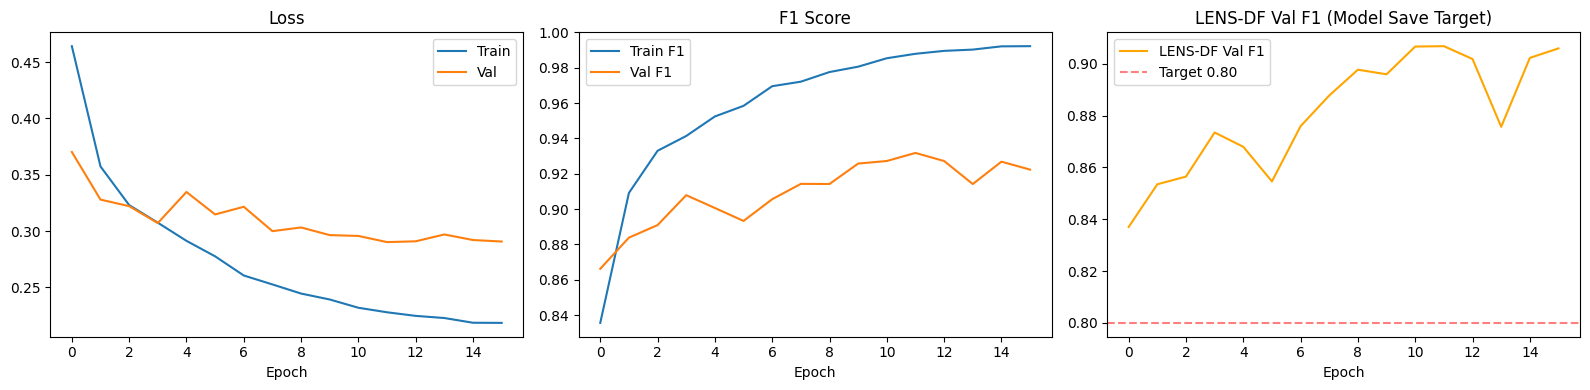

In [26]:
plot_training_curves(history)


## LENS-DF Fine-tuning

Specializes the Stage 1 model toward LENS-DF by training only on LENS-DF dev data.

**Frozen layers:** `layer1`, `layer2`, `layer3` — low-level features from Stage 1 are preserved.
**Trainable:** `layer4` + FC head — only high-level decision boundary is updated.

**Anti-leakage design:**
- 90/10 split of LENS-DF dev with seed=99 (different from Stage 1 seed=42)
- Save decision uses the 10% fine-tune val — `lensdf_test_loader` is never touched here


In [27]:
print('STAGE 2: LENS-DF FINE-TUNING')

# Load best Stage 1 checkpoint
model.load_state_dict(torch.load('best_model_phase1.pth', map_location=device))
print('Loaded best Stage 1 model')

# 90/10 split — different seed from Stage 1 (seed=42) to avoid overlap
n_ft_val   = int(len(lensdf_dev_full) * 0.1)
n_ft_train = len(lensdf_dev_full) - n_ft_val
ft_train_ds, ft_val_ds = torch.utils.data.random_split(
    lensdf_dev_full, [n_ft_train, n_ft_val],
    generator=torch.Generator().manual_seed(99)
)
ft_train_labels = [lensdf_dev_full.labels[i] for i in ft_train_ds.indices]
lens_ft_loader  = DataLoader(ft_train_ds, batch_size=BATCH_SIZE,
    sampler=make_balanced_sampler(ft_train_labels), num_workers=4, pin_memory=True)
ft_val_loader   = DataLoader(ft_val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True)
print(f'FT Train: {len(ft_train_ds):,} | FT Val: {len(ft_val_ds):,}')

# Freeze layer1-3 — only fine-tune layer4 + FC
for name, param in model.resnet.named_parameters():
    if any(x in name for x in ['layer1', 'layer2', 'layer3']):
        param.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} params (layer4 + FC only)')

# Lower LR than Stage 1 — small updates to avoid forgetting Stage 1 features
ft_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5, weight_decay=3e-4   # stronger weight decay than Stage 1
)
# T_max=10 gives scheduler room even if early stopping cuts it short
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=10, eta_min=1e-7)
ft_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Early stopping — tighter patience for fine-tuning (small dataset overfits fast)
best_ft_f1       = 0.0
ft_patience      = 0
FT_PATIENCE      = 3        # tighter than Stage 1 (was 4) — fine-tuning overfits faster
FT_MAX_EPOCHS    = 15       # allow more epochs, early stopping will cut it short

print(f'\nMax epochs: {FT_MAX_EPOCHS} | Patience: {FT_PATIENCE}\n')

for epoch in range(FT_MAX_EPOCHS):
    t_loss, _, _, _, t_f1 = run_epoch(
        model, lens_ft_loader, ft_criterion, ft_optimizer, device, train=True
    )
    _, _, _, _, ft_val_f1 = run_epoch(
        model, ft_val_loader, ft_criterion, ft_optimizer, device, train=False
    )
    ft_scheduler.step()

    print(f'FT Ep {epoch+1:02d}/{FT_MAX_EPOCHS} | '
          f'Train F1={t_f1:.4f} | FT Val F1={ft_val_f1:.4f} | '
          f'Patience={ft_patience}/{FT_PATIENCE}')

    if ft_val_f1 > best_ft_f1:
        best_ft_f1  = ft_val_f1
        ft_patience = 0        # reset on improvement
        torch.save(model.state_dict(), 'best_model_phase1.pth')
        print(f'  ✓ Saved (FT Val F1={best_ft_f1:.4f})')
    else:
        ft_patience += 1
        print(f'  No improvement ({ft_patience}/{FT_PATIENCE})')
        if ft_patience >= FT_PATIENCE:
            print(f'\n⏹ Early stopping at epoch {epoch+1} '
                  f'— no improvement for {FT_PATIENCE} epochs')
            break

print(f'\nFine-tuning complete.')
print(f'   Best FT Val F1 : {best_ft_f1:.4f}')
print(f'   Stopped at ep  : {epoch+1}/{FT_MAX_EPOCHS}')
print(f'   -> Proceed to Section 13 for final evaluation')

STAGE 2: LENS-DF FINE-TUNING
Loaded best Stage 1 model
FT Train: 9,695 | FT Val: 1,077
Trainable: 8,398,018 params (layer4 + FC only)

Max epochs: 15 | Patience: 3



FT Ep 01/15 | Train F1=0.9660 | FT Val F1=0.9699 | Patience=0/3
  ✓ Saved (FT Val F1=0.9699)


FT Ep 02/15 | Train F1=0.9658 | FT Val F1=0.9632 | Patience=0/3
  No improvement (1/3)


FT Ep 03/15 | Train F1=0.9702 | FT Val F1=0.9584 | Patience=1/3
  No improvement (2/3)


FT Ep 04/15 | Train F1=0.9710 | FT Val F1=0.9697 | Patience=2/3
  No improvement (3/3)

⏹ Early stopping at epoch 4 — no improvement for 3 epochs

Fine-tuning complete.
   Best FT Val F1 : 0.9699
   Stopped at ep  : 4/15
   -> Proceed to Section 13 for final evaluation


## Final Evaluation

Evaluates on:
1. **EnvSDD test set** — in-distribution performance
2. **LENS-DF eval set** — cross-domain generalization (the real challenge)


In [28]:
model.load_state_dict(torch.load('best_model_phase1.pth', map_location=device))
model.eval()
print('Best model loaded')

envsdd_test        = EnvSDDDataset(ENVSDD_TEST, augment=False)
envsdd_test_loader = DataLoader(envsdd_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
print(f'EnvSDD Test : {len(envsdd_test):,} samples')
print(f'LENS-DF Eval: {len(lens_test_ds):,} samples')

Best model loaded
  EnvSDD [test]: 17878 files | real=3576, fake=14302
EnvSDD Test : 17,878 samples
LENS-DF Eval: 2,000 samples


## EnvSDD Test


  Per-Class Report: EnvSDD Test Set
  Accuracy: 0.9972
              precision    recall  f1-score   support

    Real (0)     0.9922    0.9938    0.9930      3576
    Fake (1)     0.9985    0.9980    0.9983     14302

    accuracy                         0.9972     17878
   macro avg     0.9953    0.9959    0.9956     17878
weighted avg     0.9972    0.9972    0.9972     17878



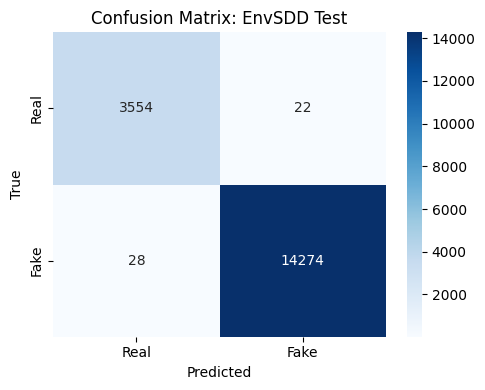

In [29]:
env_labels, env_preds = evaluate_full(model, envsdd_test_loader, device, 'EnvSDD')
env_cm = print_per_class_report(env_labels, env_preds, 'EnvSDD Test Set')
plot_confusion_matrix(env_cm, 'EnvSDD Test')

## LENS-DF Eval


  Per-Class Report: Lens-DF Eval Set
  Accuracy: 0.6870
              precision    recall  f1-score   support

    Real (0)     0.6819    0.7010    0.6913      1000
    Fake (1)     0.6924    0.6730    0.6826      1000

    accuracy                         0.6870      2000
   macro avg     0.6871    0.6870    0.6869      2000
weighted avg     0.6871    0.6870    0.6869      2000



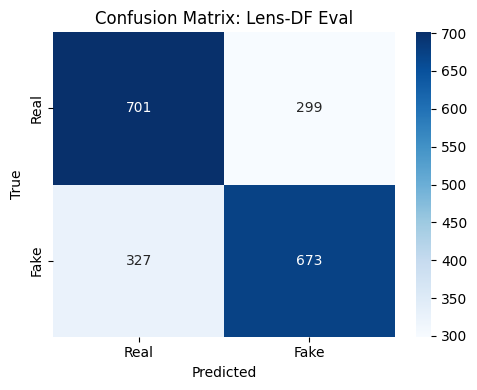

In [30]:
lens_labels, lens_preds = evaluate_full(model, lensdf_test_loader, device, 'Lens-DF')
lens_cm = print_per_class_report(lens_labels, lens_preds, 'Lens-DF Eval Set')
plot_confusion_matrix(lens_cm, 'Lens-DF Eval')

## Phase 1 Summary Table

In [31]:
 # ── Simple summary (matching your screenshot style) ───────────────────────────
print("\n" + "="*55)
print("  FINAL TEST RESULTS — LENS-DF Eval")
print("="*55)
print(f"  Loss      : {lens_loss:.4f}")
print(f"  Accuracy  : {accuracy_score(lens_labels, lens_preds):.4f}")
print(f"  F1 Score  : {f1_score(lens_labels, lens_preds, average='macro'):.4f}")
print(f"  Precision : {precision_score(lens_labels, lens_preds, pos_label=1, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(lens_labels, lens_preds, pos_label=1, zero_division=0):.4f}")

# ── Full per-dataset summary table ────────────────────────────────────────────
summary_df = pd.DataFrame({
    'EnvSDD' : row(env_labels,  env_preds),
    'Lens-DF': row(lens_labels, lens_preds),
}).T

# Format all float columns to 4 decimal places
summary_df = summary_df.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print("\n" + "="*97)
print("  PHASE 1 FINAL RESULTS")
print("="*97)
print(summary_df.to_string())
print()

summary_df.to_csv('phase1_results_summary.csv')
print("Saved to phase1_results_summary.csv")


  FINAL TEST RESULTS — LENS-DF Eval
  Loss      : 0.3706
  Accuracy  : 0.6870
  F1 Score  : 0.6869
  Precision : 0.6924
  Recall    : 0.6730

  PHASE 1 FINAL RESULTS
        Accuracy Precision Real Recall Real F1 Real Precision Fake Recall Fake F1 Fake Macro F1
EnvSDD    0.9972         0.9922      0.9938  0.9930         0.9985      0.9980  0.9983   0.9956
Lens-DF   0.6870         0.6819      0.7010  0.6913         0.6924      0.6730  0.6826   0.6869

Saved to phase1_results_summary.csv


/tmp/ipykernel_6868/1951689042.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  summary_df = summary_df.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x)


## Referances

SpecAugment
Park et al. (2019). SpecAugment: A Simple Data Augmentation Method for Automatic Speech Recognition. Interspeech 2019. https://arxiv.org/abs/1904.087

ResNet-18
He et al. (2016). Deep Residual Learning for Image Recognition. IEEE CVPR 2016. https://arxiv.org/abs/1512.03385


Instance Normalization
Ulyanov et al. (2017). Instance Normalization: The Missing Ingredient for Fast Stylization. arXiv 2017. https://arxiv.org/abs/1607.08022

AdamW Optimizer
Loshchilov and Hutter (2019). Decoupled Weight Decay Regularization. ICLR 2019. https://arxiv.org/abs/1711.05101

Label Smoothing
Müller et al. (2019). When Does Label Smoothing Help? NeurIPS 2019. https://arxiv.org/abs/1906.02629

Cosine Annealing Scheduler
Loshchilov and Hutter (2017). SGDR: Stochastic Gradient Descent with Warm Restarts. ICLR 2017. https://arxiv.org/abs/1608.03983

wav2vec 2.0 (Facebook)
Baevski et al. (2020). wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations. NeurIPS 2020. https://arxiv.org/abs/2006.11477

LENS-DF Dataset
(Authors). LENS-DF: Deepfake Detection and Temporal Localization for Long-Form Noisy Speech. arXiv 2025. https://arxiv.org/abs/2507.16220

Dropout
Srivastava et al. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. Journal of Machine Learning Research, 15, 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html